## Zadanie 1

In [40]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split


wine = load_wine()

X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.2)


knn = KNeighborsClassifier(n_neighbors=5)
knn = knn.fit(X_train, y_train)

results = knn.score(X_test, y_test)
results

0.6388888888888888

In [18]:
import numpy as np
import matplotlib.pyplot as plt

wine = load_wine()


def bootstrap_knn(n_bootstrap = 100):

    X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.2)

    accuracy = []
    n_samples = X_train.shape[0]
    for _ in range(n_bootstrap):

        sample = np.random.choice(n_samples, size=n_samples, replace=True)
        X_boot = X_train[sample]
        y_boot = y_train[sample]

        knn = KNeighborsClassifier(n_neighbors=5)
        knn = knn.fit(X_boot, y_boot)
        accuracy.append(knn.score(X_test, y_test))

    return  np.array(accuracy)


In [27]:
accuracy = bootstrap_knn(1000)

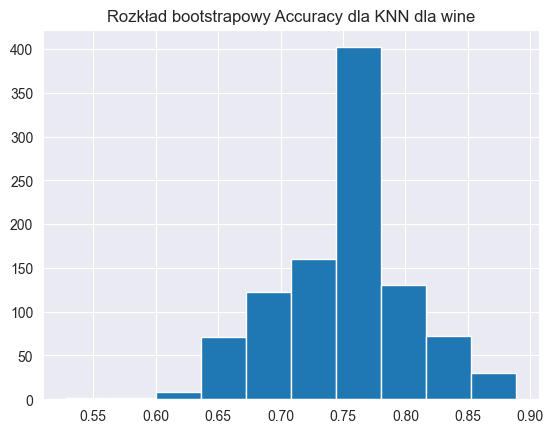

In [28]:
plt.hist(accuracy, )
plt.title("Rozkład bootstrapowy Accuracy dla KNN dla wine")
plt.show()

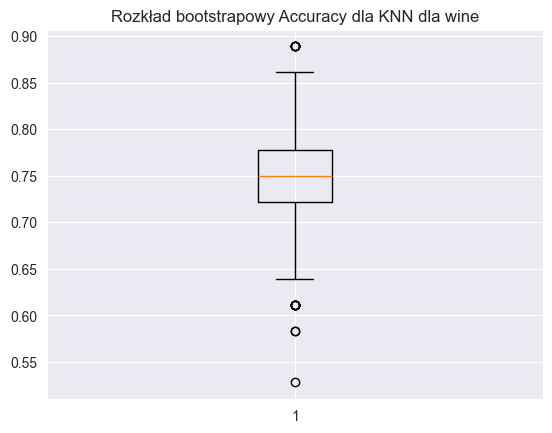

In [29]:
plt.boxplot(accuracy)
plt.title("Rozkład bootstrapowy Accuracy dla KNN dla wine")
plt.show()

In [30]:
lower = np.percentile(accuracy, 2.5)
upper = np.percentile(accuracy, 97.5)
print(lower, upper)

0.6388888888888888 0.8611111111111112


## Zadanie 2

In [58]:
import pandas as pd
import seaborn as sns
df = pd.DataFrame(wine.data, columns=wine.feature_names)

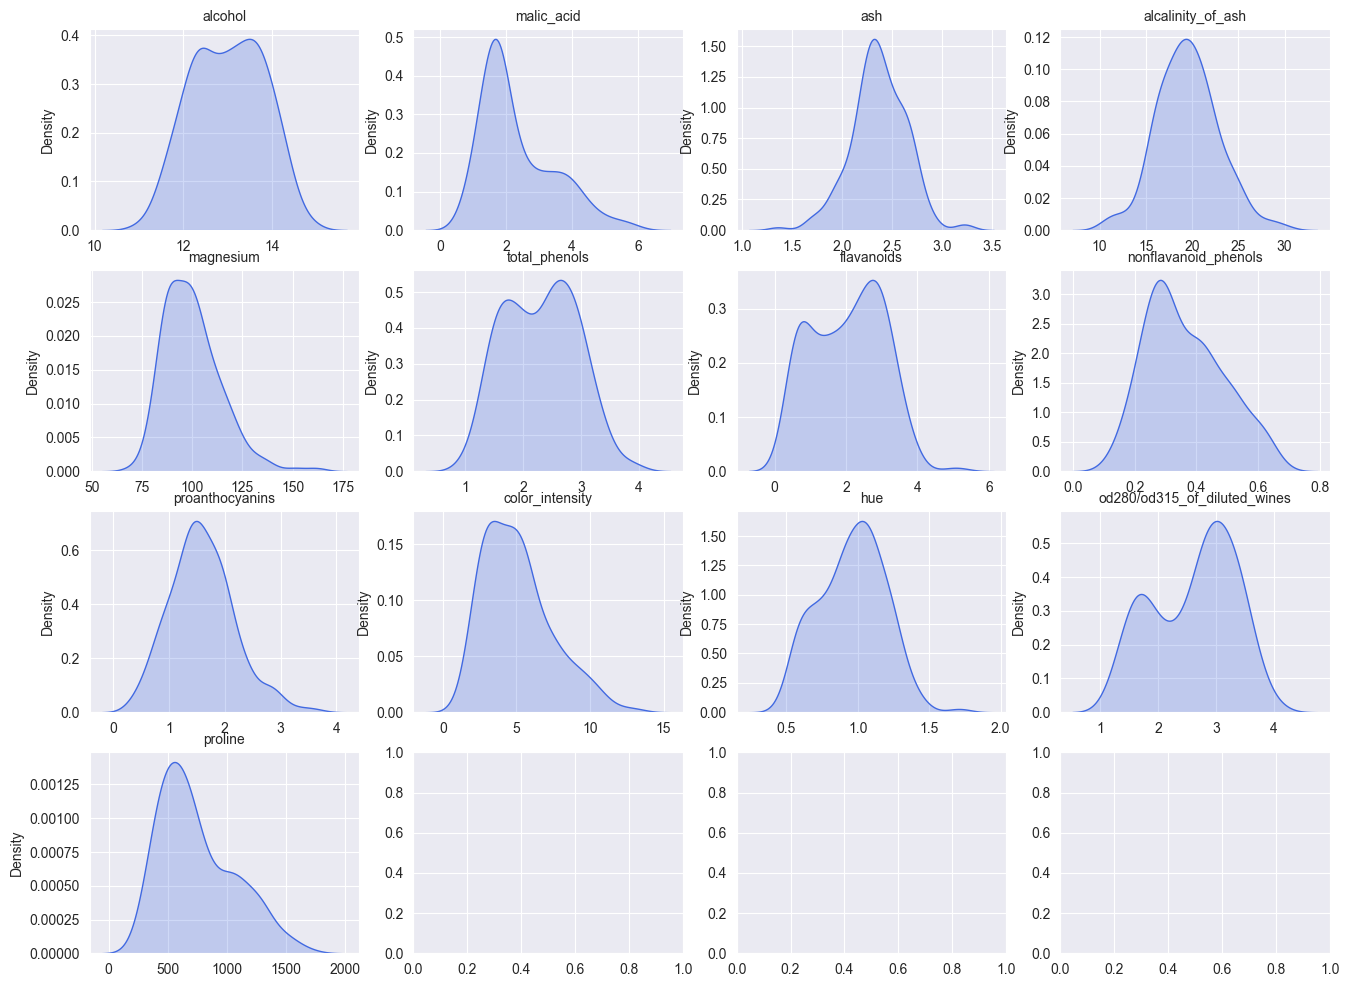

In [55]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i,col in enumerate(df.columns):
    sns.kdeplot(data=df, x=col, fill=True, ax=axes[i], color="royalblue")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")


In [60]:
relevant_features = ['malic_acid','ash','alcalinity_of_ash','magnesium','nonflavanoid_phenols','proanthocyanins','color_intensity','hue','proline']

## Zadanie 3

In [61]:
import statistics

In [63]:
correlation_matrix = df[relevant_features].corr()

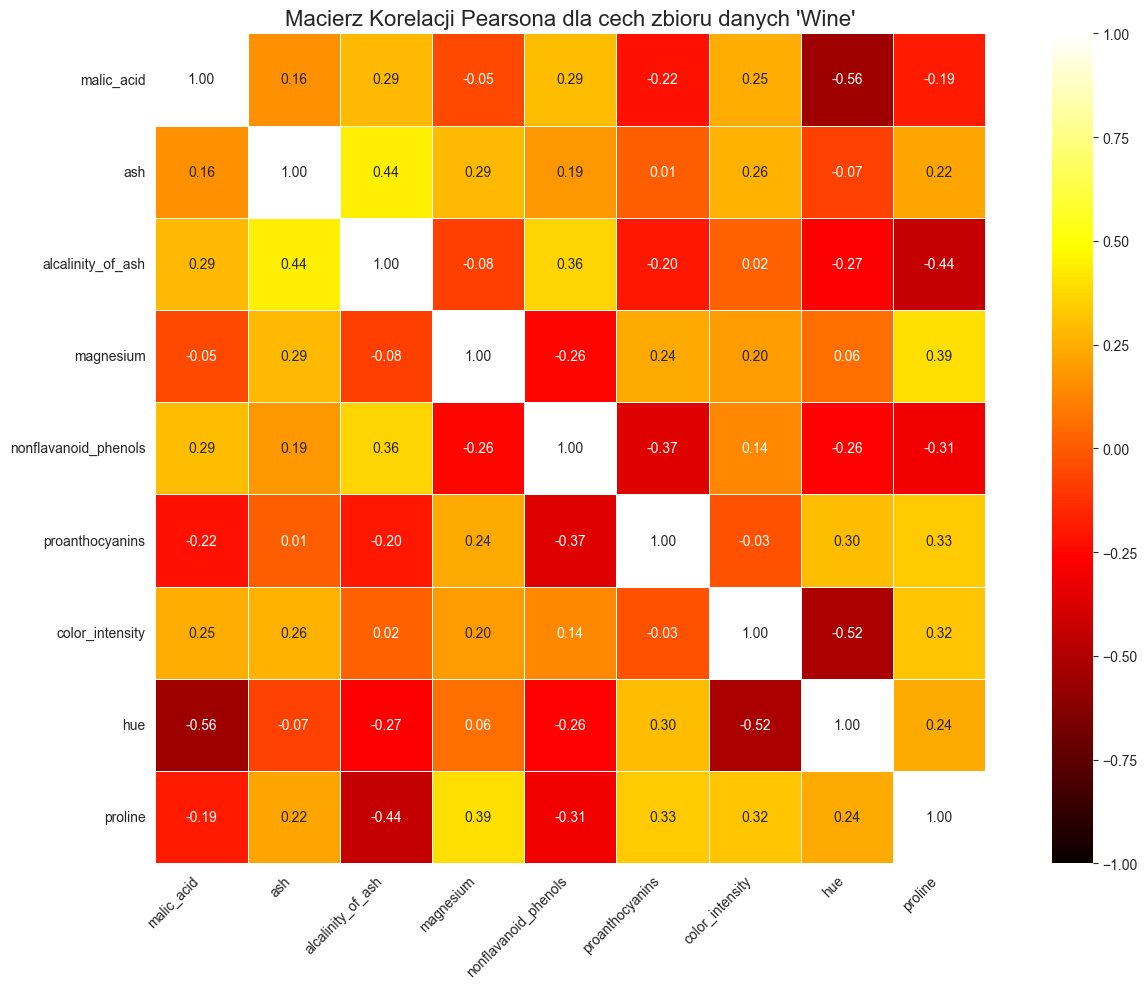

In [66]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap= 'hot',
    vmin=-1, vmax=1,
    linewidths=.5,
    square=True
)

plt.title("Macierz Korelacji Pearsona dla cech zbioru danych 'Wine'", fontsize=16)
plt.xticks(rotation=45, ha='right') # Obróć etykiety osi X dla czytelności
plt.tight_layout()
plt.show()